In [ ]:
# %% Libraries
import os
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
import anndata as ad
#import rapids_singlecell as rsc


# %% Setting Paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'v7'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb_{CUR_OBJ_V}.h5ad'


# %% Load the unintegrated object
comb = sc.read_h5ad(CUR_OBJ_PATH)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_polygon, geom_rect, geom_text,
    scale_x_continuous, labs, theme_minimal, theme,
    element_blank, element_text
)

# --------------------------
# 1) Prepare Sankey (counts)
# --------------------------
def prepare_sankey_data_from_adata(
    adata,
    col_left: str,
    col_right: str,
    na_label: str = "NA",
) -> pd.DataFrame:
    """
    Returns a df with columns: Method1, Method2, Count
    """
    if col_left not in adata.obs.columns:
        raise KeyError(f"{col_left!r} not found in adata.obs")
    if col_right not in adata.obs.columns:
        raise KeyError(f"{col_right!r} not found in adata.obs")

    left = adata.obs[col_left].astype("string").fillna(na_label)
    right = adata.obs[col_right].astype("string").fillna(na_label)

    return (
        pd.DataFrame({"Method1": left, "Method2": right})
        .groupby(["Method1", "Method2"], dropna=False)
        .size()
        .reset_index(name="Count")
    )


# -----------------------------------------
# 2) Build 2-stage alluvial plot primitives
# -----------------------------------------
@dataclass
class Alluvial2StageSpec:
    x_left: float = 1.0
    x_right: float = 2.0
    node_width: float = 0.12
    gap: float = 0.02
    n_curve: int = 40


def _sigmoid(t: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-10 * (t - 0.5)))


def build_alluvial_2stage_geometry(
    sankey_df: pd.DataFrame,
    left_col: str = "Method1",
    right_col: str = "Method2",
    value_col: str = "Count",
    fill_col: str = "Method1",
    left_order: Optional[Sequence[str]] = None,
    right_order: Optional[Sequence[str]] = None,
    spec: Alluvial2StageSpec = Alluvial2StageSpec(),
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      flows_df: polygon points for ribbons (x, y, flow_id, fill)
      nodes_df: rectangles for node strata (xmin, xmax, ymin, ymax, node, side, xmid)
      labels_df: label positions (x, y, label)
    """
    df = sankey_df.copy()
    df[left_col] = df[left_col].astype(str)
    df[right_col] = df[right_col].astype(str)

    if left_order is None:
        left_order = sorted(df[left_col].unique().tolist())
    if right_order is None:
        right_order = sorted(df[right_col].unique().tolist())

    left_totals = df.groupby(left_col, as_index=False)[value_col].sum()
    right_totals = df.groupby(right_col, as_index=False)[value_col].sum()

    # Stack nodes on the left
    y0 = 0.0
    left_ranges = {}
    for node in left_order:
        total = float(left_totals.loc[left_totals[left_col] == node, value_col].sum())
        ymin, ymax = y0, y0 + total
        left_ranges[node] = (ymin, ymax)
        y0 = ymax + spec.gap

    # Stack nodes on the right
    y0 = 0.0
    right_ranges = {}
    for node in right_order:
        total = float(right_totals.loc[right_totals[right_col] == node, value_col].sum())
        ymin, ymax = y0, y0 + total
        right_ranges[node] = (ymin, ymax)
        y0 = ymax + spec.gap

    # Left within-node stacking by right order
    df["__right_rank"] = df[right_col].map({k: i for i, k in enumerate(right_order)})
    df = df.sort_values([left_col, "__right_rank", value_col], ascending=[True, True, False]).reset_index(drop=True)

    left_offsets = {k: left_ranges[k][0] for k in left_order}
    yL0, yL1 = [], []
    for _, row in df.iterrows():
        node = row[left_col]
        v = float(row[value_col])
        start = left_offsets[node]
        end = start + v
        yL0.append(start); yL1.append(end)
        left_offsets[node] = end
    df["yL0"] = yL0
    df["yL1"] = yL1

    # Right within-node stacking by left order
    df["__left_rank"] = df[left_col].map({k: i for i, k in enumerate(left_order)})
    df = df.sort_values([right_col, "__left_rank", value_col], ascending=[True, True, False]).reset_index(drop=True)

    right_offsets = {k: right_ranges[k][0] for k in right_order}
    yR0, yR1 = [], []
    for _, row in df.iterrows():
        node = row[right_col]
        v = float(row[value_col])
        start = right_offsets[node]
        end = start + v
        yR0.append(start); yR1.append(end)
        right_offsets[node] = end
    df["yR0"] = yR0
    df["yR1"] = yR1

    # Stable flow IDs
    df = df.sort_values([left_col, right_col]).reset_index(drop=True)
    df["flow_id"] = np.arange(len(df)).astype(str)

    # Build flow polygons (top + bottom)
    xL, xR = spec.x_left, spec.x_right
    t = np.linspace(0, 1, spec.n_curve)
    s = _sigmoid(t)
    x_curve = xL + (xR - xL) * t

    polys = []
    for _, r in df.iterrows():
        y_top = r["yL1"] + (r["yR1"] - r["yL1"]) * s
        y_bot = r["yL0"] + (r["yR0"] - r["yL0"]) * s

        poly_x = np.concatenate([x_curve, x_curve[::-1]])
        poly_y = np.concatenate([y_top, y_bot[::-1]])

        polys.append(pd.DataFrame({
            "x": poly_x,
            "y": poly_y,
            "flow_id": r["flow_id"],
            "fill": r[fill_col],
        }))

    flows_df = pd.concat(polys, ignore_index=True)

    # Nodes + labels
    nodes = []
    for node, (ymin, ymax) in left_ranges.items():
        nodes.append({
            "side": "left", "node": node,
            "xmin": xL - spec.node_width/2, "xmax": xL + spec.node_width/2,
            "ymin": ymin, "ymax": ymax,
            "xmid": xL
        })
    for node, (ymin, ymax) in right_ranges.items():
        nodes.append({
            "side": "right", "node": node,
            "xmin": xR - spec.node_width/2, "xmax": xR + spec.node_width/2,
            "ymin": ymin, "ymax": ymax,
            "xmid": xR
        })
    nodes_df = pd.DataFrame(nodes)

    labels_df = nodes_df.assign(
        x=nodes_df["xmid"],
        y=(nodes_df["ymin"] + nodes_df["ymax"]) / 2,
        label=nodes_df["node"],
    )[["x", "y", "label", "side"]]

    return flows_df, nodes_df, labels_df


# --------------------------
# 3) Create the plot (no saving)
# --------------------------
def create_sankey_plot_plotnine(
    sankey_df: pd.DataFrame,
    left_name: str = "Manual",
    right_name: str = "SingleR",
    subtitle: str = "Straight flows = agreement | Crossed flows = disagreement",
) :
    flows_df, nodes_df, labels_df = build_alluvial_2stage_geometry(sankey_df)

    p = (
        ggplot()
        + geom_polygon(
            flows_df,
            aes(x="x", y="y", group="flow_id", fill="fill"),
            alpha=0.7
        )
        + geom_rect(
            nodes_df,
            aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
            fill="white",
            color="grey"
        )
        + geom_text(
            labels_df,
            aes(x="x", y="y", label="label"),
            size=8,
            fontweight="bold"
        )
        + scale_x_continuous(
            breaks=[1, 2],
            labels=[left_name, right_name],
            expand=(0.05, 0.05),
        )
        + labs(
            title=f"{left_name} vs {right_name}",
            subtitle=subtitle,
            y="Number of Cells",
            x=""
        )
        + theme_minimal()
        + theme(
            legend_position="none",
            axis_text_y=element_blank(),
            axis_title_x=element_blank(),
            plot_title=element_text(weight="bold"),
        )
    )
    return p


# --------------------------
# 4) Example usage in notebook
# --------------------------
# sankey_df = prepare_sankey_data_from_adata(
#     adata, "manual_annotation", "singler_annotation"
# )
# p = create_sankey_plot_plotnine(sankey_df, left_name="Manual", right_name="SingleR")
# p


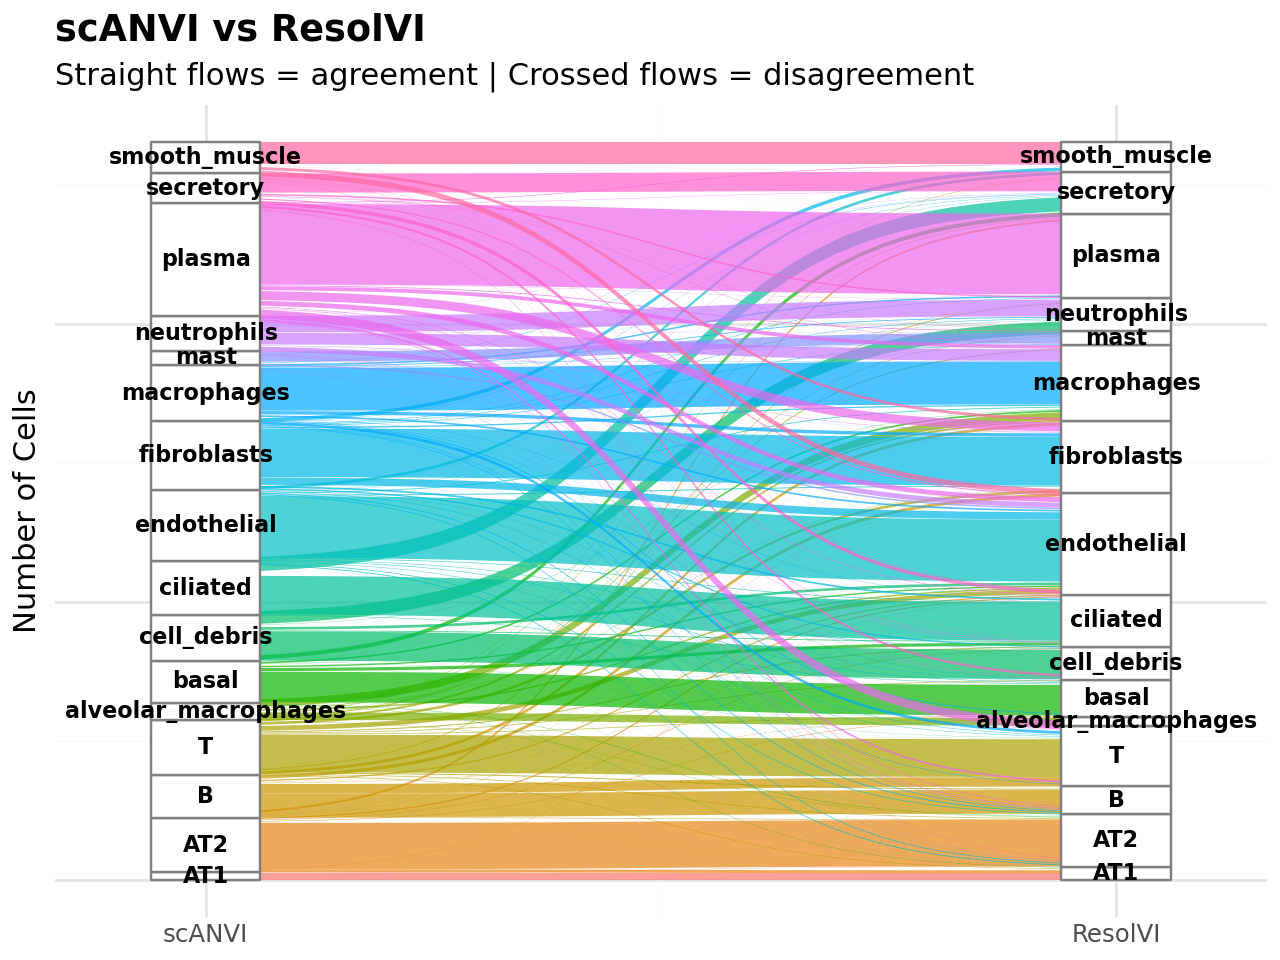

In [3]:
sankey_df = prepare_sankey_data_from_adata(comb, "ct_scANVI", "ct_resolvi")
create_sankey_plot_plotnine(sankey_df, left_name="scANVI", right_name="ResolVI")


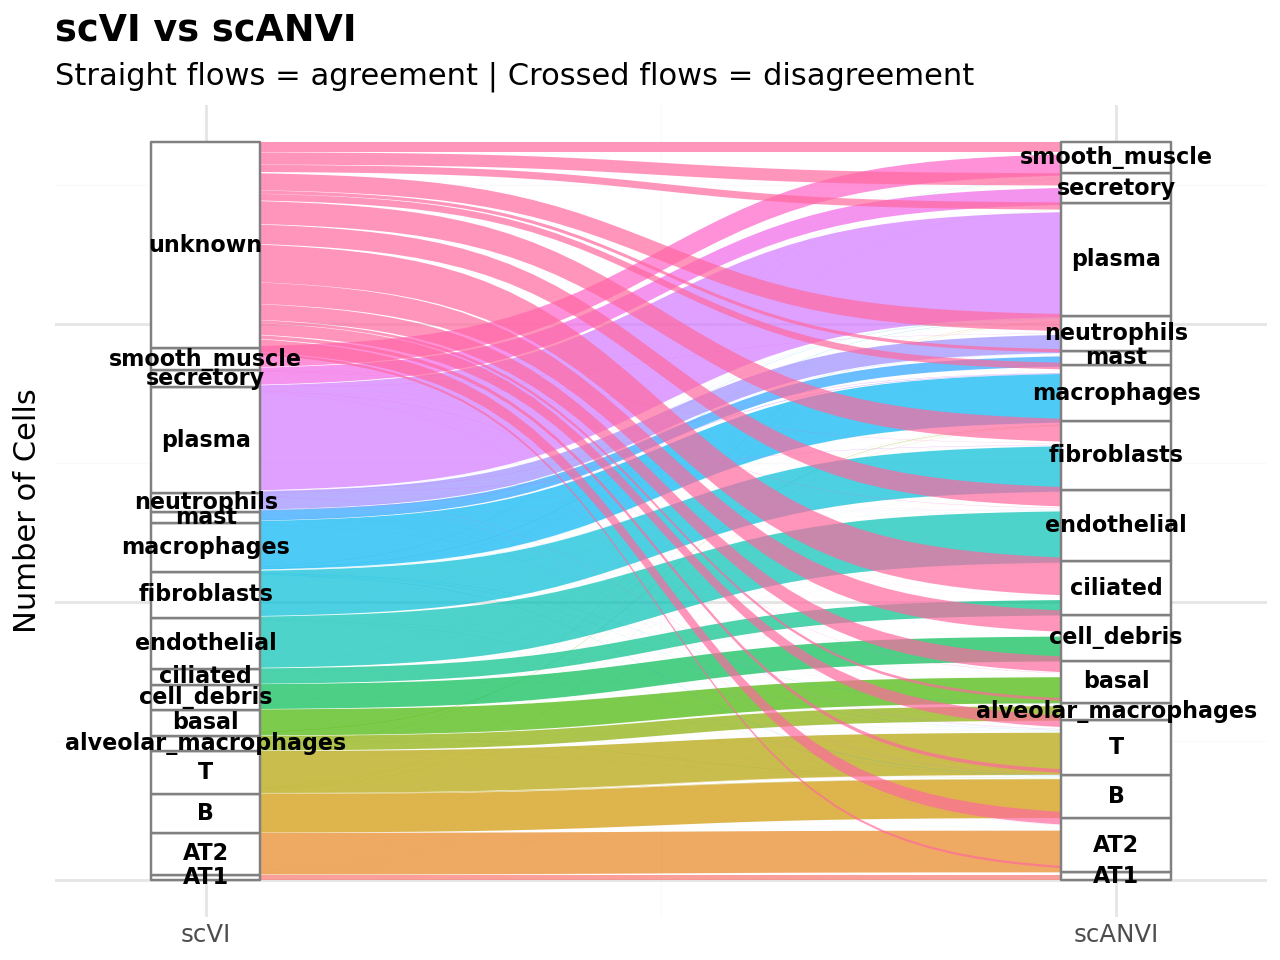

In [4]:
sankey_df = prepare_sankey_data_from_adata(comb, "ct_scVI", "ct_scANVI")
create_sankey_plot_plotnine(sankey_df, left_name="scVI", right_name="scANVI")

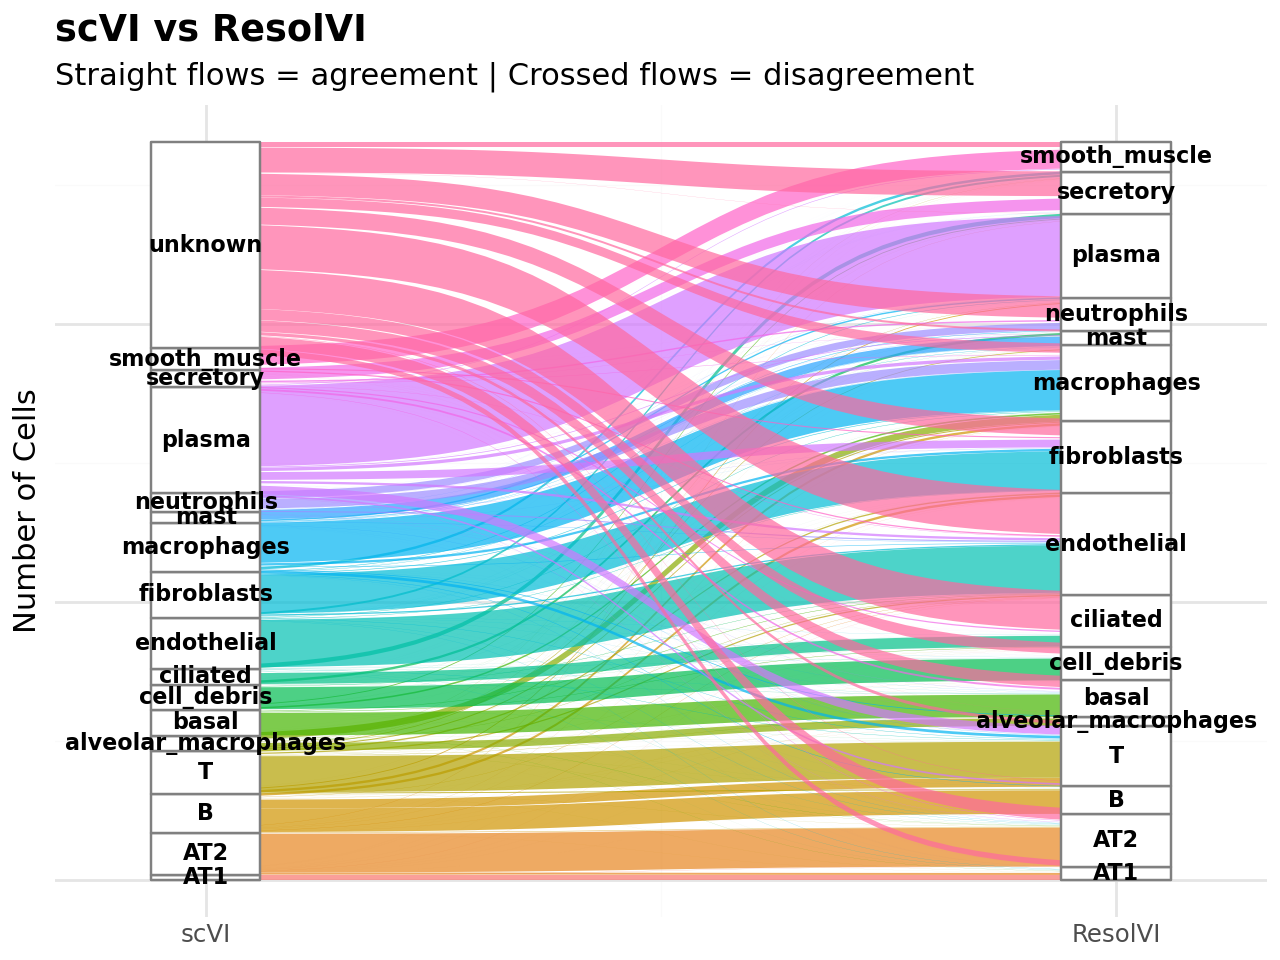

In [5]:
sankey_df = prepare_sankey_data_from_adata(comb, "ct_scVI", "ct_resolvi")
create_sankey_plot_plotnine(sankey_df, left_name="scVI", right_name="ResolVI")

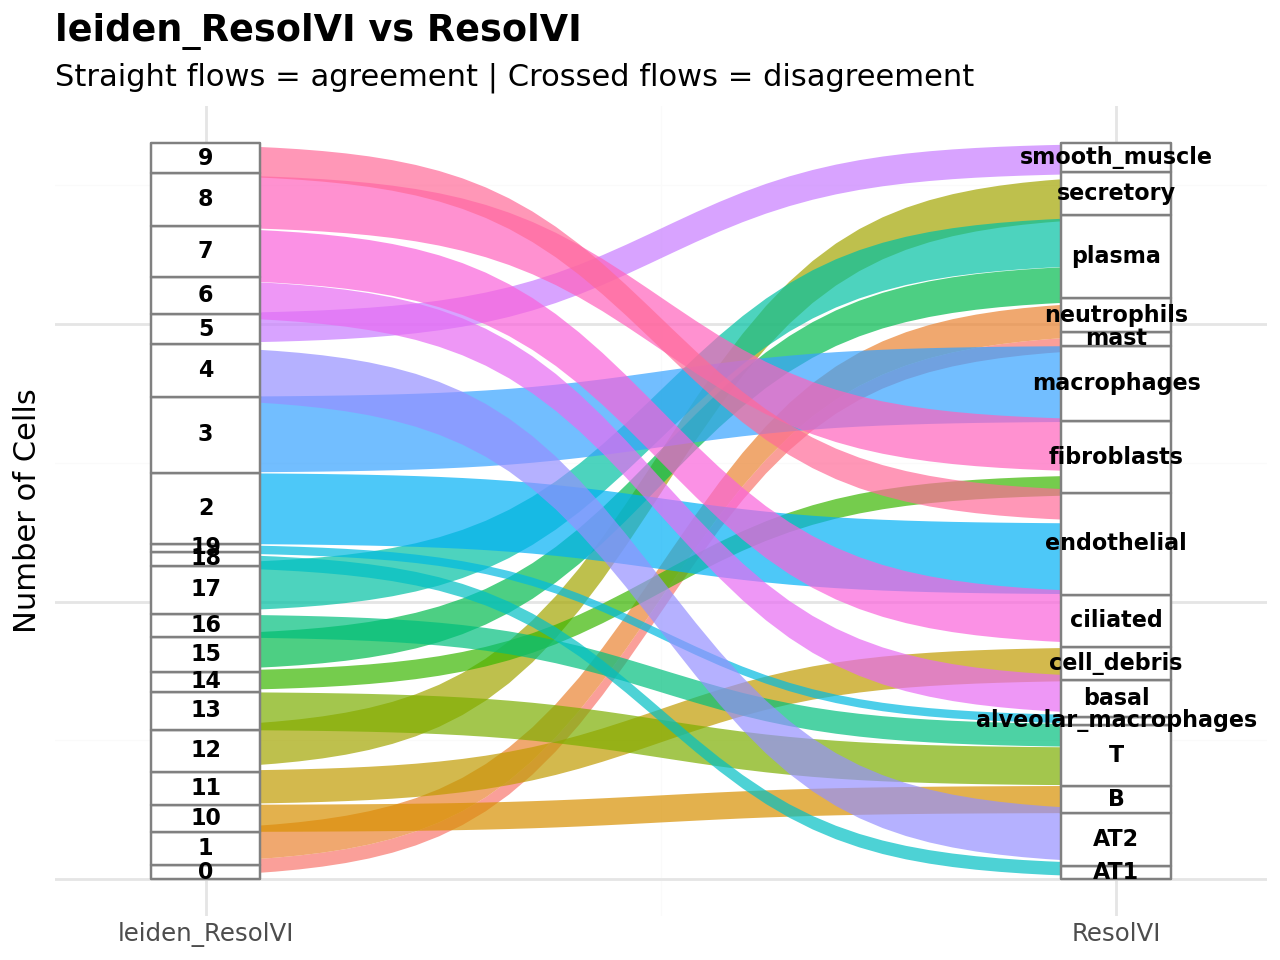

In [8]:
sankey_df = prepare_sankey_data_from_adata(comb, "leiden_resolvi", "ct_resolvi")
create_sankey_plot_plotnine(sankey_df, left_name="leiden_ResolVI", right_name="ResolVI")

In [6]:
comb

AnnData object with n_obs × n_vars = 1326786 × 6175
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'f

In [26]:
# rename classes 

classes_map = {
    
    # epithelial 
    'basal': 'epithelial',
    'secretory': 'epithelial',
    'ciliated': 'epithelial',
    'AT1': 'epithelial',
    'AT2': 'epithelial',

    # lymphoid
    'T': 'lymphoid',
    'B': 'lymphoid',
    'plasma': 'lymphoid',

    # myeloid
    'neutrophils': 'myeloid',
    'mast': 'myeloid',
    'macrophages': 'myeloid',
    'alveolar_macrophages': 'myeloid',

    # stromal
    'fibroblasts': 'stroma',
    'smooth_muscle': 'stroma',

    # endothelial
    'endothelial': 'endothelial',

    # cell debris
    'cell_debris': 'cell_debris',

}

comb.obs['ann_lvl_2'] = comb.obs['ct_resolvi'].map(classes_map).astype('category')

In [28]:
# rename classes 

lvl_1_classes_map = {
    
    # epithelial 
    'epithelial': 'epithelial',

    # immune
    'lymphoid': 'immune',
    'myeloid': 'immune',

    # stromal
    'stroma': 'stroma',

    # endothelial
    'endothelial': 'endothelial',

    # cell debris
    'cell_debris': 'cell_debris',

}

comb.obs['ann_lvl_1'] = comb.obs['ann_lvl_2'].map(lvl_1_classes_map).astype('category')

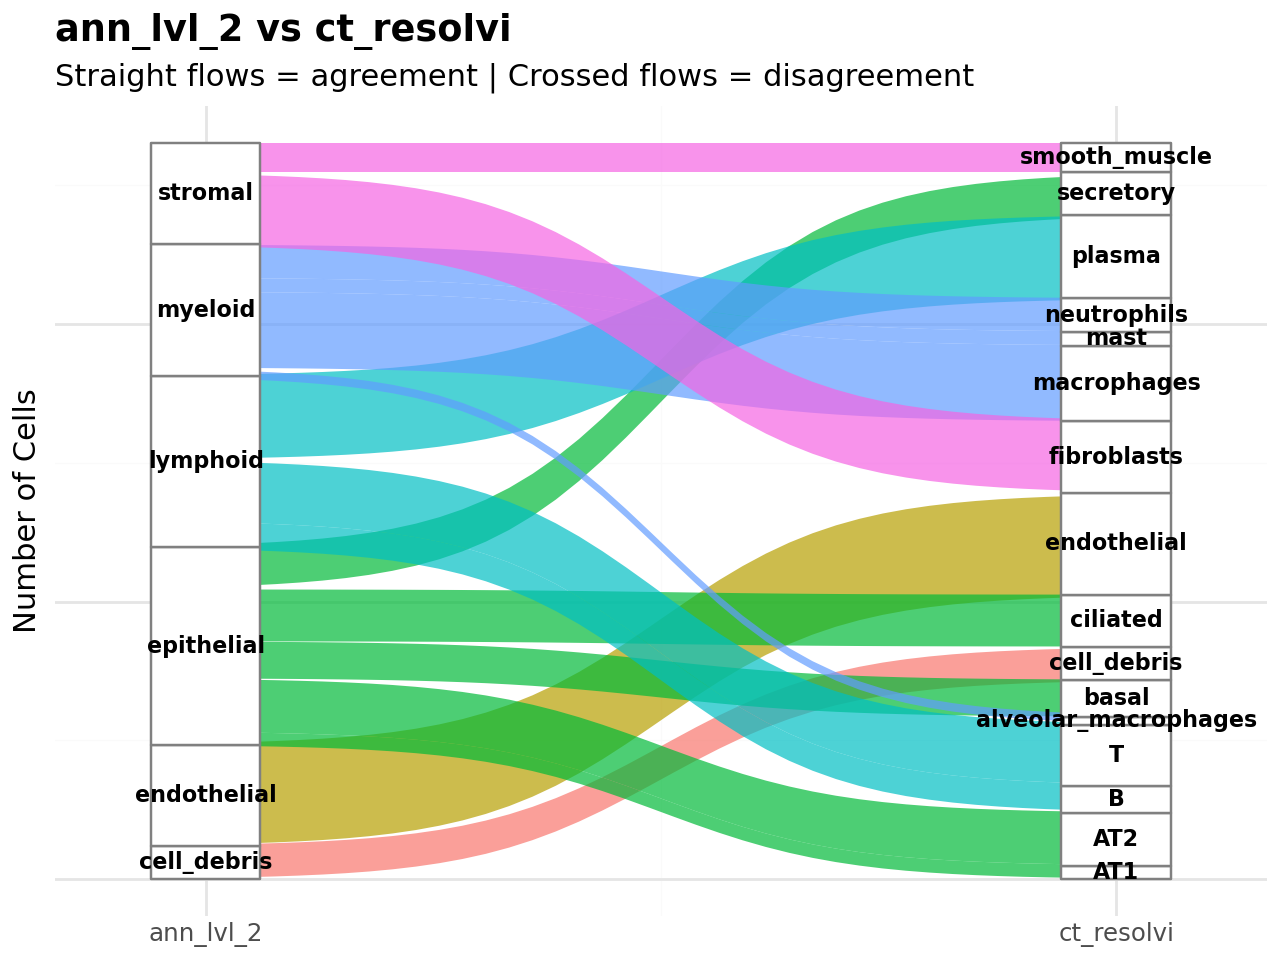

In [24]:
sankey_df = prepare_sankey_data_from_adata(comb, "ann_lvl_2", "ct_resolvi")
create_sankey_plot_plotnine(sankey_df, left_name="ann_lvl_2", right_name="ct_resolvi")

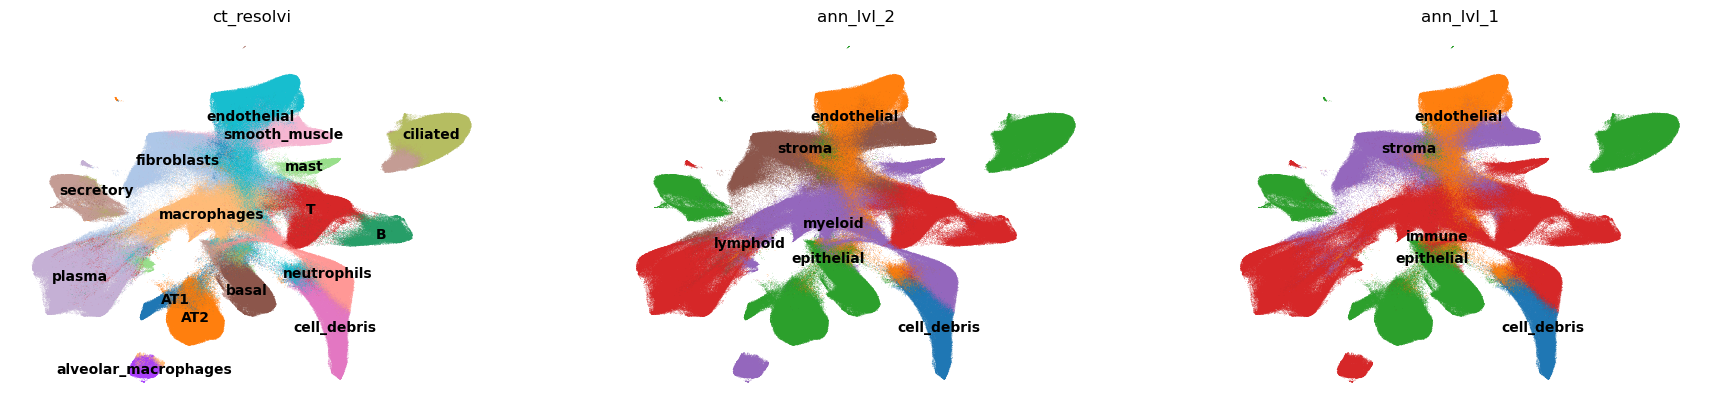

In [29]:
sc.pl.umap(
    comb,
    color=['ct_resolvi', 'ann_lvl_2', 'ann_lvl_1'],
    size=0.5,
    frameon=False,
    legend_loc='on data',
    return_fig = False,
    show=True,
)

['#f0a0ff', '#0075dc', '#993f00', '#4c005c', '#191919', '#005c31', '#2bce48', '#ffcc99', '#808080', '#94ffb5', '#8f7c00', '#9dcc00', '#c20088', '#003380', '#ffa405', '#ffa8bb', '#426600', '#ff0010', '#5ef1f2', '#00998f', '#e0ff66', '#740aff', '#990000', '#ffff80', '#ffe100', '#ff5005']


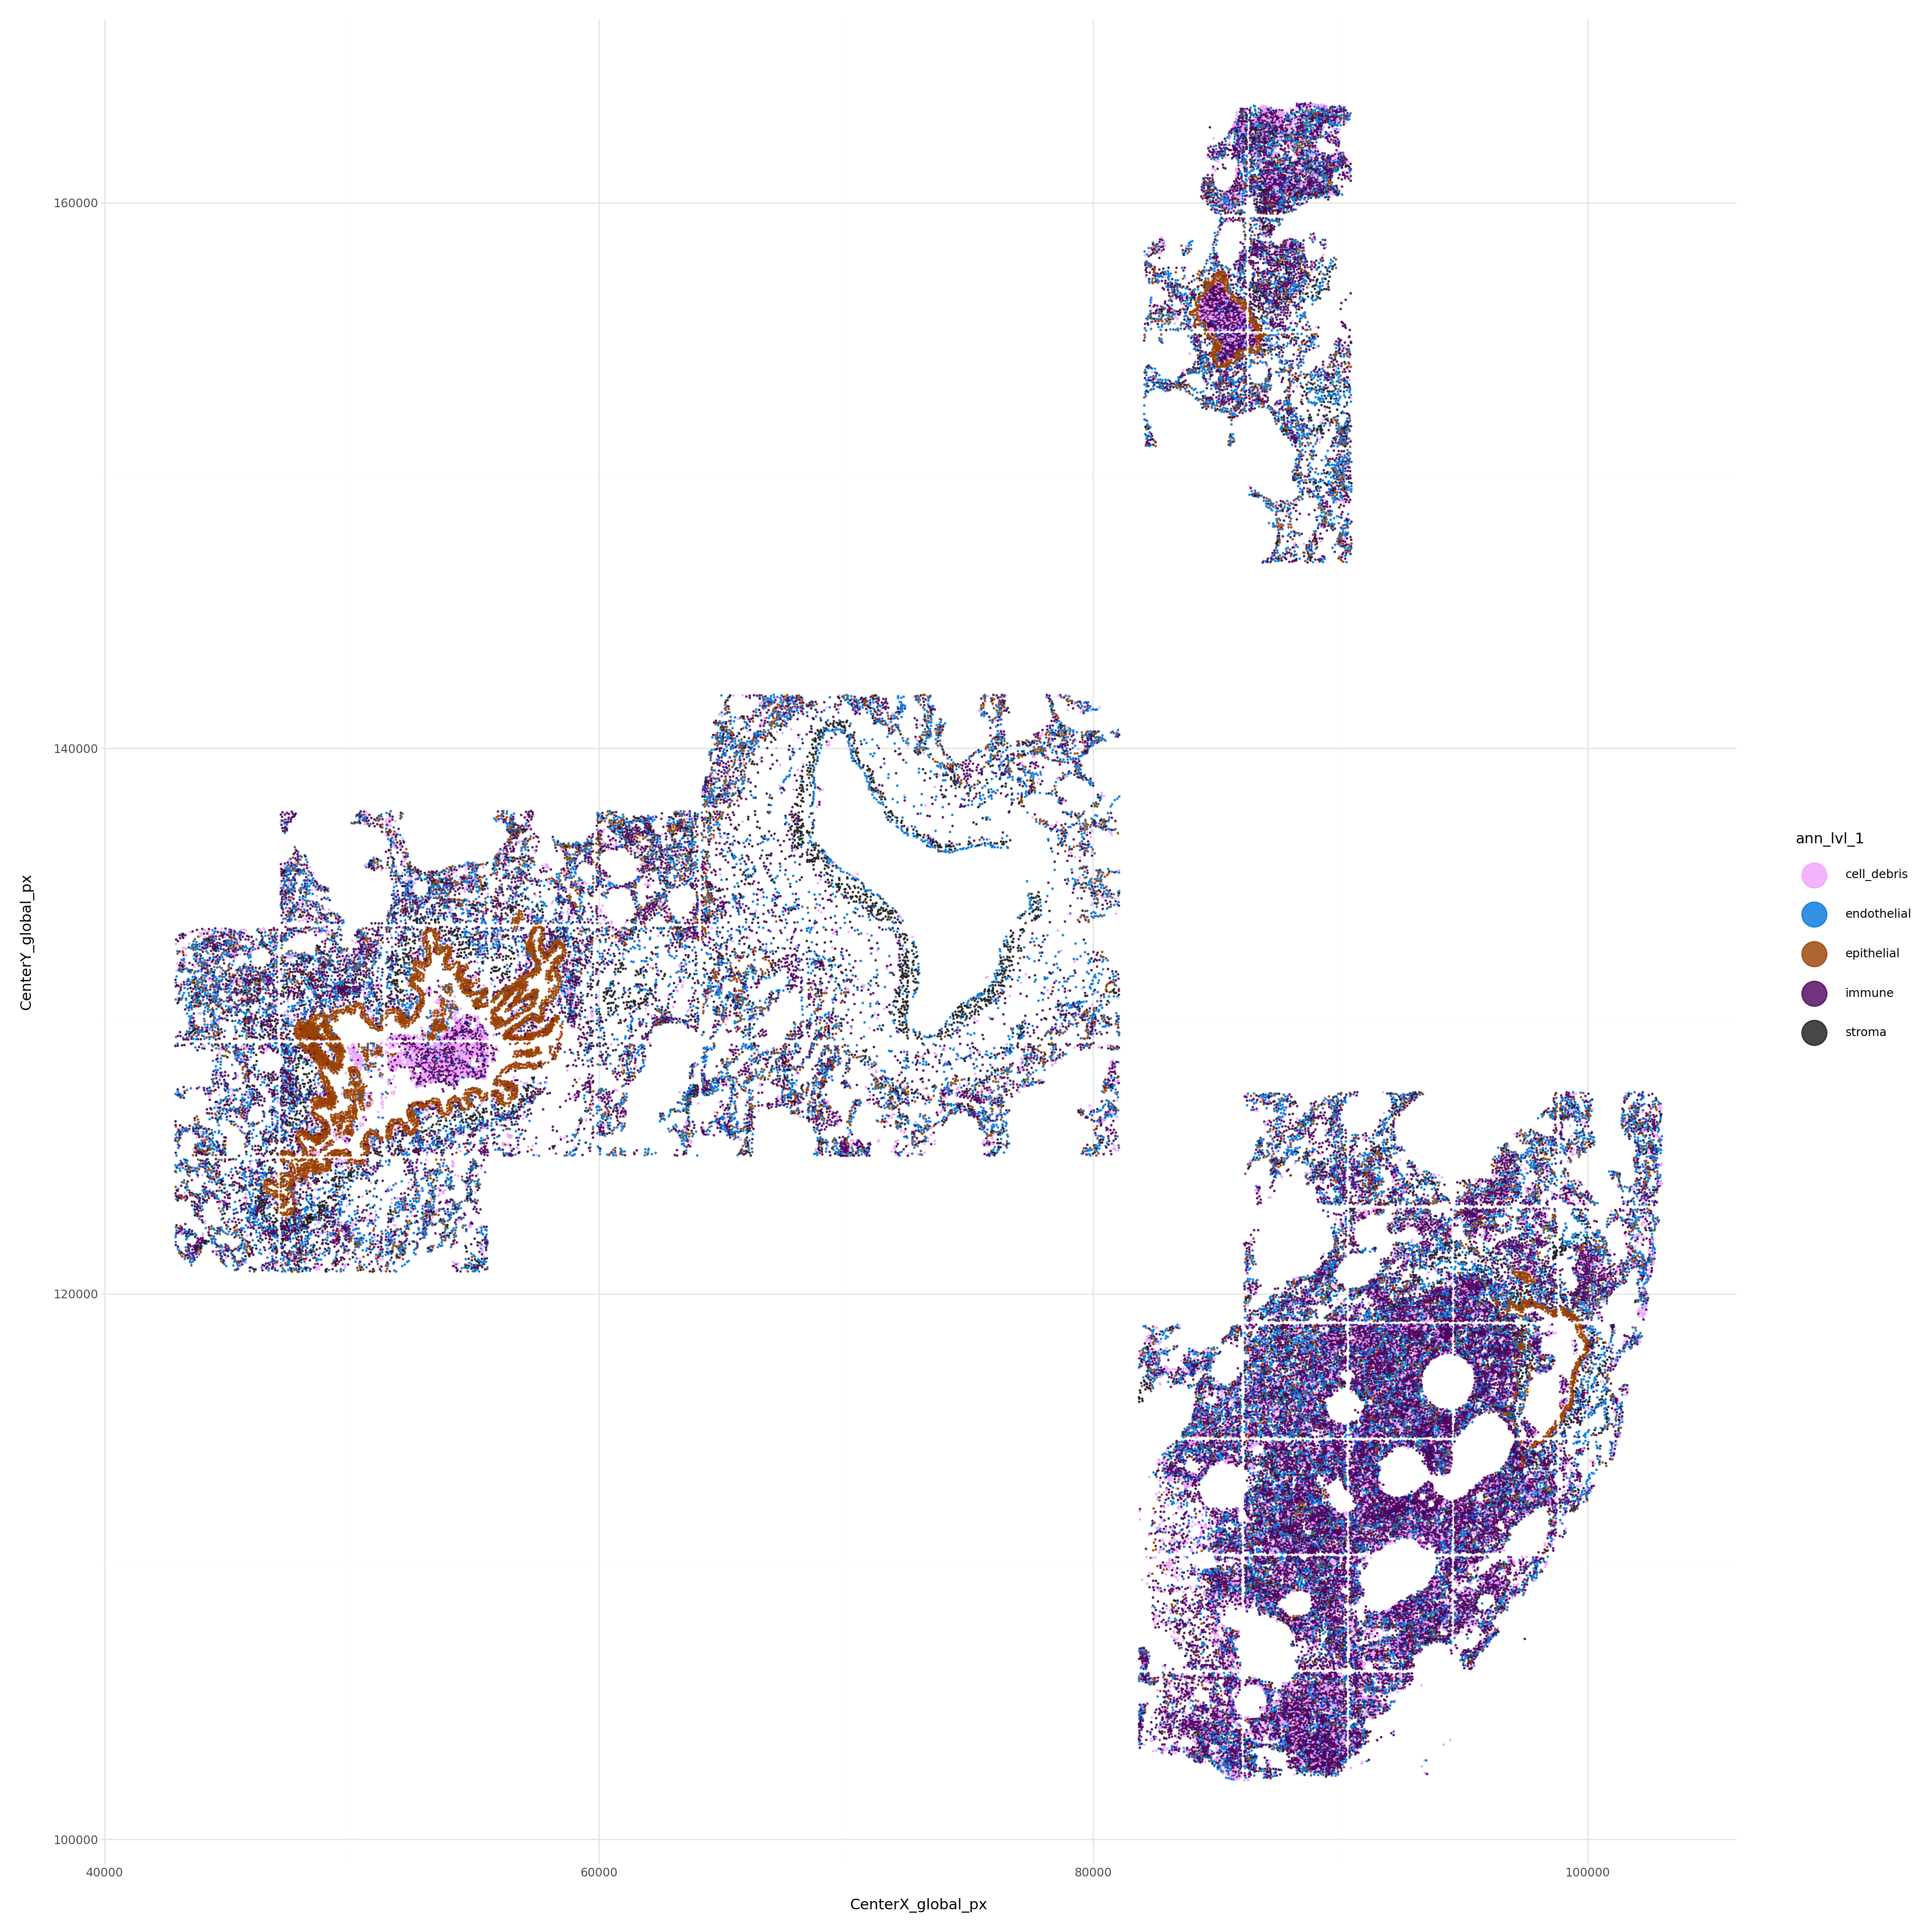

In [31]:
# %% Check for spatial location of clusters CTRL01

SAMPLE_NAME = 'CTRL01'

sample_df = comb.obs[comb.obs['sample_name']==SAMPLE_NAME].copy()

import pypalettes as pp

# Load the colormap
cmap = pp.load_cmap("alphabet")

# Get N discrete colors as hex
n = 26
palette = [cmap(i / (n-1)) for i in range(n)]

# Convert RGBA -> hex
import matplotlib.colors as mcolors
palette = [mcolors.to_hex(c) for c in palette]

print(palette)


import plotnine as p9

(
    p9.ggplot(sample_df, p9.aes(x='CenterX_global_px', y='CenterY_global_px', color='ann_lvl_1'))
    + p9.geom_point(size=0.1, alpha=0.8)
    + p9.scale_color_manual(values=palette)
    + p9.theme_minimal()
    + p9.theme(figure_size=(20, 20))
    + p9.guides(color=p9.guide_legend(override_aes={'size': 10}))  # increase legend dot size
)